# 09 — Analyse, Visualisierung und Ergebnisgeschichte

## Zweck
Die geprüften Gold-Daten in eine nachvollziehbare, **deskriptive** Ergebnisgeschichte übersetzen.
Sechs Abbildungen belegen die Befunde. Der Fokus liegt auf wissenschaftlicher Ehrlichkeit:
jede Aussage wird nur so weit getroffen, wie die Daten sie tragen.

## Analysevertrag (was wir NICHT behaupten)
- **Keine Kausalität.** Wir beschreiben Zusammenhänge, erklären keine Ursachen.
- **Keine allgemeingültige Stadtrangliste.** Es gilt nur der geladene Beobachtungszeitraum.
- **Keine Vermischung der Quellen.** EEA sind **gemessene** Werte, Open-Meteo sind **Modellwerte** —
  sie werden getrennt dargestellt und nie direkt verglichen.
- **Bevölkerungsdichte nur explorativ.** Bei acht Städten ist kein statistischer Beweis möglich.

## Forschungsfrage und Hypothesen
**Leitfrage:** Wie unterscheiden sich PM2.5-, PM10- und NO2-Muster zwischen den acht Städten,
und wie lässt sich das durch städtischen Kontext vorsichtig einordnen?

- **H1:** Die mittleren PM2.5-Werte unterscheiden sich zwischen den Städten.
- **H2:** Die Rangfolge ist schadstoffabhängig — PM2.5, PM10 und NO2 müssen getrennt betrachtet werden.
- **H3:** Bevölkerungsdichte hängt explorativ mit den Werten zusammen, ist aber kein Erklärungsfaktor.
- **H4:** Der Open-Meteo-Live-Snapshot ergänzt die Architektur, ersetzt aber keine historische Messung.

## Daten laden und Umfang offenlegen
**Wissenschaftlicher Grundsatz:** zuerst den Datenumfang zeigen, dann interpretieren. Die Zelle gibt
Zeitraum, Städtezahl, Schadstoffe und — entscheidend — ob der Zeitraum für **finale** Aussagen reicht.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
GOLD_DIR = DATA_DIR / "gold"
FIGURE_DIR = PROJECT_ROOT / "presentation" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")
UNIT = "µg/m³"
WHO_2021_ANNUAL = {"pm2_5": 5, "pm10": 15, "no2": 10}  # WHO-2021 Jahresrichtwerte (µg/m³)

daily = pd.read_parquet(GOLD_DIR / "city_air_quality_daily_summary.parquet")
ranking = pd.read_parquet(GOLD_DIR / "pollutant_ranking_by_city.parquet")
context = pd.read_parquet(GOLD_DIR / "city_context_air_quality.parquet")
live = pd.read_parquet(GOLD_DIR / "live_air_quality_latest.parquet")
quality = pd.read_parquet(GOLD_DIR / "data_quality_summary.parquet")

daily["date"] = pd.to_datetime(daily["date"])
days_loaded = int(daily["date"].nunique())

print("Gold-Tabellen (aus dem Qualitätsbericht):")
print(quality.to_string(index=False))

scope = {
    "Zeitraum": f"{daily['date'].min().date()} bis {daily['date'].max().date()}",
    "Verschiedene Tage": days_loaded,
    "Städte": daily["city_id"].nunique(),
    "Schadstoffe": sorted(daily["pollutant"].unique()),
}
scope

Gold-Tabellen (aus dem Qualitätsbericht):
                         table  rows  columns  missing_values  coverage_days
city_air_quality_daily_summary  7938       11               0            365
     pollutant_ranking_by_city    22        8               0            365
      city_context_air_quality    22       13               0            365
       live_air_quality_latest     8        7               0           <NA>


{'Zeitraum': '2025-01-01 bis 2025-12-31',
 'Verschiedene Tage': 365,
 'Städte': 8,
 'Schadstoffe': ['no2', 'pm10', 'pm2_5']}

### Wie die Aussagen zu lesen sind
Alle Aussagen sind **deskriptiv** und gelten **nur für den oben gezeigten Zeitraum**. Umfasst er ein
volles Jahr, beschreiben sie dieses Jahr; ist er kürzer, gelten sie entsprechend nur für diese Tage —
keine Verallgemeinerung auf andere Zeiträume oder Kausalität.

In [2]:
SCOPE_NOTE = (f"Datengrundlage: {days_loaded} Tage "
              f"({daily['date'].min().date()} bis {daily['date'].max().date()}). "
              "Alle Aussagen sind deskriptiv und gelten nur für diesen Zeitraum.")
print(SCOPE_NOTE)

Datengrundlage: 365 Tage (2025-01-01 bis 2025-12-31). Alle Aussagen sind deskriptiv und gelten nur für diesen Zeitraum.


### Beobachtungszahlen und Abdeckung
Rangfolgen sind nur sinnvoll, wenn ihre Datenbasis sichtbar ist. Wir zeigen je Stadt und Schadstoff
die Zahl der Tageswerte. **Fehlende Kombinationen werden offen ausgewiesen, nicht aufgefüllt** — eine
fehlende Abdeckung erscheint als `<NA>`, nicht als `0`. So fehlen z. B. für **Rom** im Zeitraum
geprüfte PM2.5/PM10-Stationen; Rom erscheint daher nur bei NO2 und bleibt aus den PM-Abbildungen
und -Rangfolgen ausgeschlossen (es wird **nicht** als 0 µg/m³ dargestellt).

In [3]:
coverage = (daily.groupby(["city_name", "pollutant"])["date"].nunique()
            .unstack("pollutant").reindex(columns=["pm2_5", "pm10", "no2"]))
missing_combos = [(c, p) for c in coverage.index for p in coverage.columns if pd.isna(coverage.loc[c, p])]
print("Fehlende Stadt/Schadstoff-Kombinationen:", missing_combos or "keine")
coverage.astype("Int64")   # fehlende Abdeckung bleibt als <NA> sichtbar (nicht als 0 dargestellt)

Fehlende Stadt/Schadstoff-Kombinationen: [('Rome', 'pm2_5'), ('Rome', 'pm10')]


pollutant,pm2_5,pm10,no2
city_name,,,
Amsterdam,351,351,353
Berlin,365,365,365
Madrid,365,365,365
Paris,365,365,365
Prague,365,365,365
Rome,<NA>,<NA>,364
Vienna,348,348,348
Warsaw,365,365,365


## Abbildung 1 — PM2.5-Städtevergleich (H1)
Mittlerer PM2.5-Wert je Stadt mit **Fehlerbalken (Standardabweichung der Tageswerte)**. Die Fehlerbalken
zeigen die Streuung: Städte mit großer Streuung haben instabilere Werte. Städte ohne PM2.5-Daten
erscheinen nicht und werden separat genannt.

## Maßstab: WHO-2021-Luftgüte-Richtwerte

Damit die Stadt-Mittelwerte einordbar werden, vergleichen wir sie mit den **WHO-2021-Jahresrichtwerten** (Jahresmittel): **PM2.5 = 5**, **PM10 = 15**, **NO2 = 10** µg/m³. Diese Werte erscheinen in den folgenden Abbildungen als gestrichelte Referenzlinien. Sie sind ein **Gesundheits-Orientierungswert**, keine gesetzliche EU-Grenze – die EU-Grenzwerte sind höher. Der Vergleich bleibt deskriptiv.


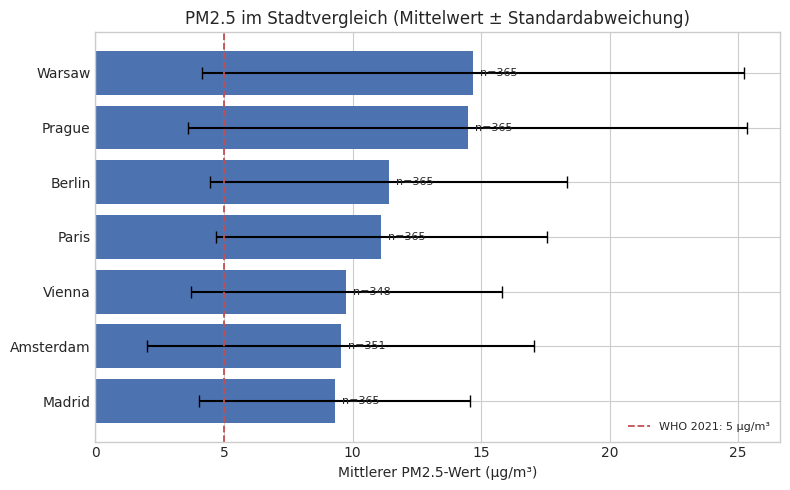

Städte ohne PM2.5-Daten: ['Rome']


In [4]:
pm25 = daily[daily["pollutant"] == "pm2_5"]
stats = (pm25.groupby("city_name")["avg_value"].agg(["mean", "std", "count"])
         .sort_values("mean"))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(stats.index, stats["mean"], xerr=stats["std"].fillna(0), capsize=4, color="#4C72B0")
for y, (mean, n) in enumerate(zip(stats["mean"], stats["count"])):
    ax.text(mean, y, f"  n={n}", va="center", fontsize=8)
ax.set_xlabel(f"Mittlerer PM2.5-Wert ({UNIT})")
ax.axvline(WHO_2021_ANNUAL["pm2_5"], color="#C44E52", ls="--", lw=1.3,
           label=f"WHO 2021: {WHO_2021_ANNUAL['pm2_5']} {UNIT}")
ax.legend(loc="lower right", fontsize=8)
ax.set_title("PM2.5 im Stadtvergleich (Mittelwert ± Standardabweichung)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pm25_city_ranking.png", dpi=120)
plt.show()
print("Städte ohne PM2.5-Daten:", sorted(set(daily['city_name']) - set(stats.index)) or "keine")

**Befund (H1):** Die mittleren PM2.5-Werte unterscheiden sich zwischen den Städten. Die Fehlerbalken
überlappen teils — Unterschiede zwischen *benachbart* gereihten Städten sind daher mit Vorsicht zu lesen.
Die annotierten `n` zeigen, auf wie vielen Tageswerten jeder Mittelwert beruht. *Es gilt der Geltungs-Hinweis.*

## Abbildung 2 — Schadstoffe nebeneinander (H2)
PM2.5, PM10 und NO2 je Stadt als Gruppenbalken. So wird sichtbar, dass die **Rangfolge vom Schadstoff
abhängt** — eine Stadt kann bei NO2 vorn liegen, bei PM2.5 aber nicht.

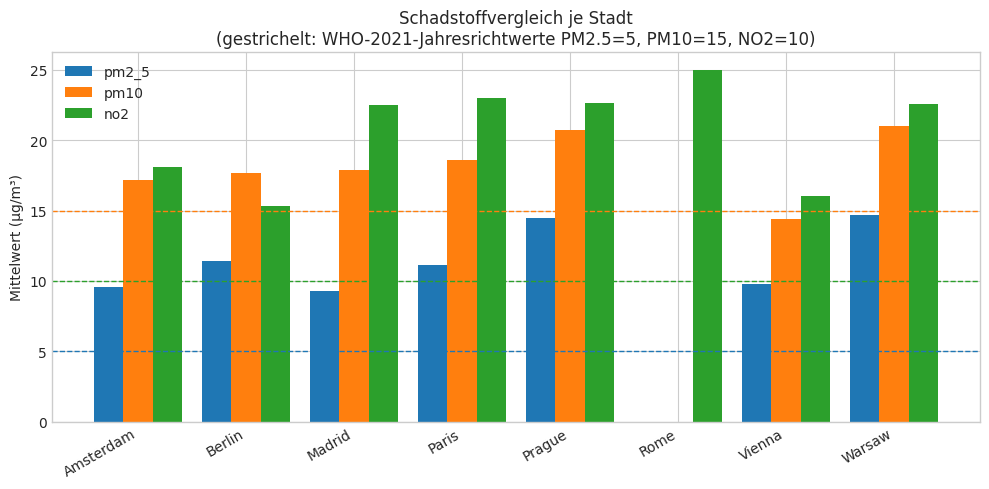

In [5]:
pivot = daily.groupby(["city_name", "pollutant"])["avg_value"].mean().unstack("pollutant")
pivot = pivot.reindex(columns=["pm2_5", "pm10", "no2"])
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot.index))
width = 0.27
for i, pol in enumerate(["pm2_5", "pm10", "no2"]):
    ax.bar(x + (i - 1) * width, pivot[pol], width, label=pol)
who_colors = {"pm2_5": "C0", "pm10": "C1", "no2": "C2"}
for pol in ["pm2_5", "pm10", "no2"]:
    ax.axhline(WHO_2021_ANNUAL[pol], color=who_colors[pol], ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(pivot.index, rotation=30, ha="right")
ax.set_ylabel(f"Mittelwert ({UNIT})")
ax.set_title("Schadstoffvergleich je Stadt\n(gestrichelt: WHO-2021-Jahresrichtwerte PM2.5=5, PM10=15, NO2=10)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pollutant_comparison.png", dpi=120)
plt.show()

**Befund (H2):** Die Rangfolge ist schadstoffabhängig. NO2 (verkehrsgeprägt) und PM (Feinstaub,
u. a. Heizung/Witterung) folgen unterschiedlichen Mustern. Deshalb darf es **keine einzelne
„Luftqualitäts-Rangliste"** geben — jeder Schadstoff wird einzeln betrachtet.

## Abbildung 3 — Tagesverlauf PM2.5 (ohne Interpolation)
Tageswerte der datenreichsten Städte. **Lücken bleiben Lücken** (keine Interpolation), damit fehlende
Tage nicht als Messwerte missverstanden werden.

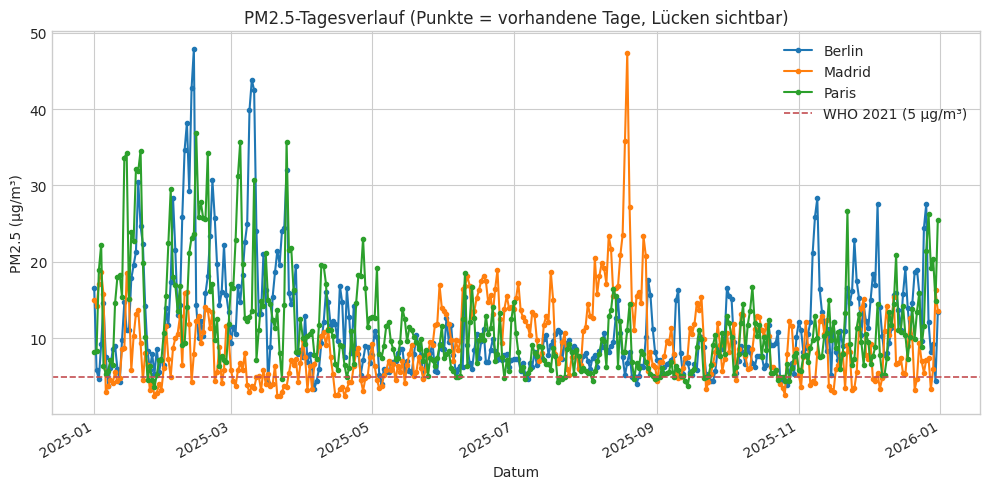

In [6]:
top_cities = pm25.groupby("city_name")["date"].nunique().sort_values(ascending=False).head(3).index
fig, ax = plt.subplots(figsize=(10, 5))
for city in top_cities:
    s = pm25[pm25["city_name"] == city].sort_values("date")
    ax.plot(s["date"], s["avg_value"], marker="o", ms=3, label=city)
ax.set_ylabel(f"PM2.5 ({UNIT})"); ax.set_xlabel("Datum")
ax.set_title("PM2.5-Tagesverlauf (Punkte = vorhandene Tage, Lücken sichtbar)")
ax.axhline(WHO_2021_ANNUAL["pm2_5"], color="#C44E52", ls="--", lw=1.2,
           label=f"WHO 2021 ({WHO_2021_ANNUAL['pm2_5']} {UNIT})")
ax.legend(); fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "selected_city_timeseries.png", dpi=120)
plt.show()

**Befund:** Der Verlauf zeigt die **Tag-zu-Tag-Schwankung**, die hinter den Mittelwerten steckt.
Einzelne hohe Tage (z. B. Inversionswetterlagen im Winter) können einen Mittelwert spürbar heben —
ein weiterer Grund, Mittelwerte zusammen mit der Streuung (Abb. 1) zu lesen.

## Abbildung 4 — Verteilungen mit Ausreißern
Boxplots der Tageswerte je Schadstoff. Sie zeigen Median, Quartile und Ausreißer — Information,
die ein reiner Mittelwert verbirgt.

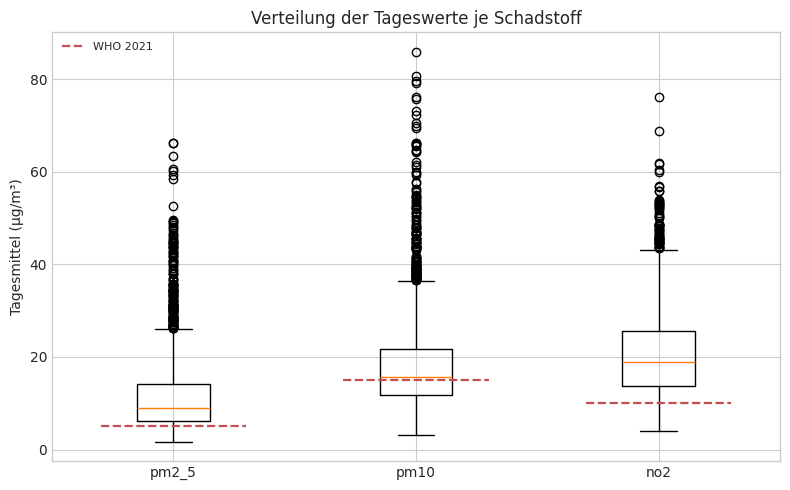

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
data = [daily[daily["pollutant"] == p]["avg_value"].dropna() for p in ["pm2_5", "pm10", "no2"]]
ax.boxplot(data, tick_labels=["pm2_5", "pm10", "no2"], showfliers=True)
for pos, pol in enumerate(["pm2_5", "pm10", "no2"], start=1):
    ax.hlines(WHO_2021_ANNUAL[pol], pos - 0.3, pos + 0.3,
              color="#C44E52", ls="--", lw=1.6,
              label="WHO 2021" if pos == 1 else None)
ax.legend(loc="upper left", fontsize=8)
ax.set_ylabel(f"Tagesmittel ({UNIT})")
ax.set_title("Verteilung der Tageswerte je Schadstoff")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pollutant_distribution.png", dpi=120)
plt.show()

**Befund:** Die Verteilungen sind **rechtsschief** (einzelne hohe Tage). Das ist typisch für
Luftschadstoffe und bestätigt, dass Mediane und Quartile neben dem Mittelwert betrachtet werden sollten.

## Abbildung 5 — Bevölkerungsdichte und PM2.5 (H3, explorativ)
Streudiagramm: Stadt-Mittelwert PM2.5 gegen Bevölkerungsdichte. **Wichtig:** bei nur acht Städten ist
dies eine **explorative Einordnung**, kein statistischer Test. Der Korrelationswert dient nur der
groben Orientierung.

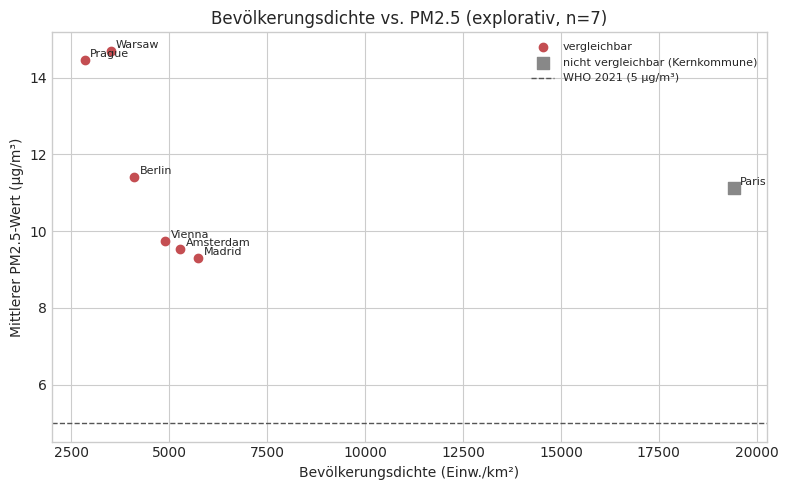

Explorativer Pearson-r (alle Städte,        n=7): -0.23
Explorativer Pearson-r (nur vergleichbare,  n=6): -0.95
Hinweis: Paris — Kernkommune (20 Arrondissements, ~105 km²) — nicht mit den größeren Verwaltungsflächen der anderen Städte vergleichbar (MAUP).
KEIN Signifikanztest, nur grobe Orientierung. Der Vergleich der beiden r-Werte zeigt, wie stark ein nicht-vergleichbarer Hebelpunkt das Ergebnis verschiebt.


In [8]:
ctx = context[context["pollutant"] == "pm2_5"].dropna(subset=["population_density", "avg_value"]).copy()
# Vergleichbarkeits-Flag aus den Metadaten; fehlt es (aeltere Daten), konservativ als vergleichbar werten.
if "density_comparable" not in ctx.columns:
    ctx["density_comparable"] = True
ctx["density_comparable"] = ctx["density_comparable"].fillna(True).astype(bool)
comparable = ctx[ctx["density_comparable"]]
flagged = ctx[~ctx["density_comparable"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(comparable["population_density"], comparable["avg_value"],
           color="#C44E52", label="vergleichbar")
ax.scatter(flagged["population_density"], flagged["avg_value"],
           color="#888888", marker="s", s=70, label="nicht vergleichbar (Kernkommune)")
for _, r in ctx.iterrows():
    ax.annotate(r["city_name"], (r["population_density"], r["avg_value"]),
                fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.set_xlabel("Bevölkerungsdichte (Einw./km²)")
ax.set_ylabel(f"Mittlerer PM2.5-Wert ({UNIT})")
ax.axhline(WHO_2021_ANNUAL["pm2_5"], color="#555555", ls="--", lw=1,
           label=f"WHO 2021 ({WHO_2021_ANNUAL['pm2_5']} {UNIT})")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Bevölkerungsdichte vs. PM2.5 (explorativ, n=%d)" % len(ctx))
fig.tight_layout()
fig.savefig(FIGURE_DIR / "density_vs_air_quality.png", dpi=120)
plt.show()


def pearson(df):
    return np.corrcoef(df["population_density"], df["avg_value"])[0, 1] if len(df) >= 3 else float("nan")


print(f"Explorativer Pearson-r (alle Städte,        n={len(ctx)}): {pearson(ctx):.2f}")
print(f"Explorativer Pearson-r (nur vergleichbare,  n={len(comparable)}): {pearson(comparable):.2f}")
if not flagged.empty:
    print("Hinweis: " + "; ".join(f"{r['city_name']} — {r['area_basis_note']}" for _, r in flagged.iterrows()))
print("KEIN Signifikanztest, nur grobe Orientierung. Der Vergleich der beiden r-Werte zeigt, "
      "wie stark ein nicht-vergleichbarer Hebelpunkt das Ergebnis verschiebt.")

**Befund (H3):** Der Zusammenhang ist **nicht robust**: über alle Städte liegt er nahe null, klammert
man die nicht-vergleichbare Stadt **Paris** aus, dreht er auf deutlich negativ (siehe die zwei
Korrelationswerte oben). Schon diese Instabilität zeigt, dass Bevölkerungsdichte die Unterschiede
**nicht** erklärt — bei sechs bis acht Städten und ohne Signifikanztest ist das reine Exploration.
Heizverhalten, Geografie, Witterung und Verkehr wirken mindestens ebenso stark.

**Einschränkung (Vergleichbarkeit):** Die Dichte von **Paris** beruht auf der **Kernkommune**
(~105 km², 20 Arrondissements), während die anderen Städte als größere Verwaltungsgebiete geführt
werden — ein *Modifiable Areal Unit Problem*. Paris wirkt dadurch als **Hebelpunkt** und ist im
Streudiagramm bewusst gesondert markiert; seine Dichte ist mit den anderen Städten **nicht direkt
vergleichbar**. Der zusätzlich ausgewiesene Korrelationswert **ohne** die nicht-vergleichbaren Städte
macht transparent, wie stark das Gesamtergebnis von dieser einen Stadt abhängt.

## Abbildung 6 — Open-Meteo-Live-Snapshot (H4, getrennt)
Der Live-Snapshot stammt aus dem Kafka-/Spark-Pfad und ist ein **Modellwert zu einem Zeitpunkt**.
Er wird **getrennt** dargestellt und nicht mit den historischen EEA-Messungen vermischt.

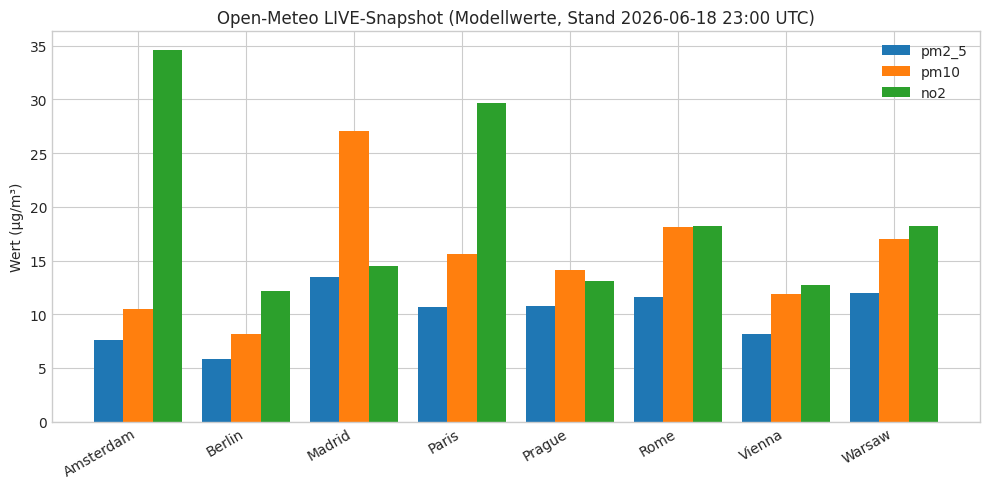

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(live["city_name"]))
width = 0.27
for i, pol in enumerate(["pm2_5", "pm10", "no2"]):
    ax.bar(x + (i - 1) * width, live[pol], width, label=pol)
ax.set_xticks(x); ax.set_xticklabels(live["city_name"], rotation=30, ha="right")
ax.set_ylabel(f"Wert ({UNIT})")
snapshot_time = pd.to_datetime(live["event_time_ts"]).max()
ax.set_title(f"Open-Meteo LIVE-Snapshot (Modellwerte, Stand {snapshot_time:%Y-%m-%d %H:%M} UTC)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "live_air_quality_snapshot.png", dpi=120)
plt.show()

**Befund (H4):** Der Snapshot zeigt, dass der Streaming-Pfad funktioniert und plausible aktuelle Werte
liefert. Er ist eine **Momentaufnahme aus einem Vorhersagemodell**, kein historischer Messwert, und
taugt daher nicht für Trend- oder Rangaussagen.

## Gesamtfazit
- **H1 bestätigt (deskriptiv):** Die Städte unterscheiden sich messbar bei PM2.5 — im Rahmen des
  Geltungs-Hinweises und der gezeigten Streuung.
- **H2 bestätigt:** Die Rangfolge hängt vom Schadstoff ab; eine einzelne Rangliste wäre irreführend.
- **H3 offen/schwach:** Bevölkerungsdichte ist nur ein vorsichtiger Kontext, keine Erklärung.
- **H4 bestätigt:** EEA-historisch und Open-Meteo-live bleiben methodisch getrennt.

**Grenzen:** je nach Lauf kurzer Zeitraum, unvollständige EEA-Stationsabdeckung (einzelne Städte können
bei einem Schadstoff fehlen), kleine Städtezahl. Alle Aussagen sind **deskriptiv und explorativ**.

## Nächster Schritt
Notebook `10` ausführen — Daten zurücksetzen und Infrastruktur herunterfahren.

## Quellen & ergänzende Recherche

- **WHO Global Air Quality Guidelines (2021)** – Jahresrichtwerte PM2.5 5, PM10 15, NO2 10 µg/m³. WHO, *WHO global air quality guidelines* (2021).
- **Saisonalität**: Winterliche PM-Spitzen durch Hausbrand/Heizung und Inversionswetterlagen; NO2 überwiegend verkehrsgeprägt (Copernicus/CAMS, *Winter air quality*).
- **Datenquellen des Projekts**: EEA Air Quality Downloads (gemessene Historie), Wikipedia (städtische Metadaten), Open-Meteo Air Quality API (Live-Modellwerte).

*Hinweis:* Live-Werte (Open-Meteo) sind Stundenwerte aus einem Modell und werden bewusst **nicht** gegen die WHO-*Jahres*richtwerte gestellt – sie dienen nur dem Kafka/Spark-Nachweis und der Momentaufnahme.
